In [1]:
from typing import TypedDict,Annotated,List,Literal
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage,SystemMessage
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph,END,MessagesState
from langgraph.prebuilt import create_react_agent,ToolNode
from langgraph.checkpoint.memory import MemorySaver



In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [3]:
class AgentState(MessagesState):
    next_agent:str #next agent info
@tool
def search_web(query:str)-> str:
    """Search the web for information"""
    search = TavilySearchResults(max_results=3)
    result= search.invoke(query)
    return str(result)
@tool
def write_summary(content:str)-> str:
    """write summary of a provided content"""
    summary=f"Summary of findings:\n\n{content[:500]}..."
    
    return summary



In [4]:
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x0000019A88541550>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000019A88542270>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
def researcher_agent(state:AgentState):
    """Researcher agents that searches for information"""
    messages=state['messages']
    system_msg=SystemMessage(content='you are a research assisstant. use the search_web tool to find insights')
    #LLM with tools
    researcher_llm=llm.bind_tools([search_web])
    response=researcher_llm.invoke([system_msg]+messages)
    return{
        "messages":[response],
        "next_agent":"writer"
    }


In [6]:
"""def create_minimal_multi_agent():"""
         #"""Minimal multi-agent system using just LLM"""
   # """def researcher_node(state:MessagesState):
    #   prompt=[
     #       SystemMessage(content="you are a researcher.Analyze the user's question and provide details.")
      #      *messages
       # ]
        #response=llm.invoke(prompt)
        #return {"messages":[response]}"""


'def create_minimal_multi_agent():'

In [7]:
def writer_agent(state:AgentState):
    """Writer agent that creates summary"""
    messages=state['messages']
    system_msg=SystemMessage(content="you are a technical writer. Review the conversation and creates a summary")
    response=llm.invoke([system_msg]+messages)
    return{
        "messages":[response],
        "next_agent":"writer"}
def execute_tools(state:AgentState):
    """EXecute any pendin tool calls"""
    messages=state["messages"]
    last_message=messages[-1]
    if hasattr(last_message,"tool_calls") and last_message.tool_calls:
        tool_node=ToolNode([search_web,write_summary])
        response=tool_node.invoke(state)
        return response
    return state


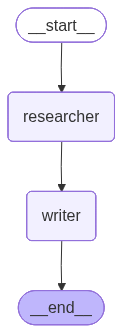

In [9]:
workflow=StateGraph(MessagesState)
workflow.add_node("researcher",researcher_agent)
workflow.add_node("writer",writer_agent)
workflow.set_entry_point('researcher')
workflow.add_edge('researcher',"writer")
workflow.add_edge("writer",END)
final_workflow=workflow.compile()
print(final_workflow)
from IPython.display import Image,display
display(Image(final_workflow.get_graph().draw_mermaid_png()))

In [10]:
final_workflow.invoke({'messages':"research about the use case of machine learning in the field of artificial intelligence"""})

{'messages': [HumanMessage(content='research about the use case of machine learning in the field of artificial intelligence', additional_kwargs={}, response_metadata={}, id='b1d7a864-ea8b-400f-9963-609ef838eb8e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ce88ackk7', 'function': {'arguments': '{"query":"machine learning artificial intelligence applications use case"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 240, 'total_tokens': 260, 'completion_time': 0.032352631, 'prompt_time': 0.015234252, 'queue_time': 0.048013538, 'total_time': 0.047586883}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7b3cfae3af', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--9885adf9-db41-4459-8d39-ca02b6c96848-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'machine learning artificial intelligence applicatio